# 實作圖轉矩陣

 給一張圖，試著使用 kernel  做出 Feature Map 

# 1. 影像轉矩陣的數學原理:
在數位世界中，一張圖片其實是一個三維張量（3D Tensor）。  

從以下維度來拆解：  
空間維度：  
像素 (Pixels)一張解析度為 $1920 \times 1080$ 的動畫截圖，代表水平方向有 1920 個點，垂直方向有 1080 個點。每一個點（像素）就是矩陣中的一個元素。  

數值維度：  
色彩空間 (Color Space)最常見的是 RGB 模型。每一張彩色圖片由三個顏色通道組成：紅 (Red)、綠 (Green)、藍 (Blue)。每個通道都是一個獨立的二維矩陣。  

矩陣中的每個數值通常介於 0 到 255 之間（8-bit 存儲），代表該顏色的強度。$0$：完全黑暗。$255$：該顏色最強。   

數學表示若一張圖片大小為 $H \times W$（高 $\times$ 寬），則它在電腦裡可以表示為：$$A \in \mathbb{R}^{H \times W \times 3}$$


如果是灰階圖片，矩陣就是 $H \times W$；  
如果是彩色圖片，Kernel（卷積核）通常也需要有 3 個層次來對應 RGB。

程式碼使用 .convert("L") 時，PIL 會根據公式（通常是 $L = R \times 299/1000 + G \times 587/1000 + B \times 114/1000$）將彩色資訊壓縮成單一數值。

In [1]:
# 實作轉成灰階矩陣
from PIL import Image
import numpy as np

# 數學意義：使用 .convert("L") 時，PIL 會根據公式（通常是 $L = R \times 299/1000 + G \times 587/1000 + B \times 114/1000$）將彩色資訊壓縮成單一數值。

img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png").convert("L")
arr = np.array(img)
print(arr)
print(arr.shape)

[[167 166 168 ...  54  51  49]
 [166 166 169 ...  53  51  49]
 [166 167 169 ...  52  53  50]
 ...
 [ 43  44  44 ...  93  94  94]
 [ 43  43  44 ...  94  94  94]
 [ 43  43  44 ...  94  94  94]]
(1080, 1920)


In [ ]:
# 實作轉彩色矩陣：
from PIL import Image
import numpy as np

img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png")
arr = np.array(img)
print(arr)
print(arr.shape)
# 第四個 為透明度 
# 這代表這張圖片除了 R (紅)、G (綠)、B (藍) 之外，還多了一個 A (Alpha，透明度) 通道。這種格式稱為 RGBA。
# 建議把第 4 個（Alpha）去掉，只保留 RGB

rgb_arr = arr[:, :, :3] 
print(rgb_arr.shape)


[[[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  ...
  [ 35  24  13 255]
  [ 35  24  13 255]
  [ 35  24  13 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  ...
  [ 35  24  13 255]
  [ 35  24  13 255]
  [ 35  24  13 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  ...
  [ 35  24  13 255]
  [ 35  24  13 255]
  [ 35  24  13 255]]

 ...

 [[ 71  68  71 255]
  [ 74  72  75 255]
  [ 89  87  90 255]
  ...
  [191 146  68 255]
  [191 146  68 255]
  [191 146  68 255]]

 [[ 70  68  71 255]
  [ 73  71  74 255]
  [ 89  87  90 255]
  ...
  [191 146  68 255]
  [191 146  68 255]
  [191 146  68 255]]

 [[ 70  68  71 255]
  [ 73  71  74 255]
  [ 89  87  90 255]
  ...
  [191 146  68 255]
  [191 146  68 255]
  [191 146  68 255]]]
(1080, 1920, 4)
(1080, 1920, 3)


In [4]:
# 實驗1：印出左上角 10×10
print(arr[:9, :9])
# 實驗2：顯示單一通道
red = arr[:,:,0]
green = arr[:,:,1]
blue = arr[:,:,2]
print(red)

[[[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]]

 [[ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23  14 255]
  [ 32  23

# 實作上要先將影像矩陣縮小
重點是減少運算次數
業界常選用 (224,224)，但考量動畫圖是 16:9 的比例，就用這個比例即可，因此我選用 (216,384)  
利用程式碼: img_small = img.resize((216, 384))  


執行 resize((224, 224)) 時，程式並不是隨機刪除格子，而是透過插值法 (Interpolation) 計算出新的像素值。  
想像你有一張大桌子（大矩陣），現在要把它縮成一張小凳子（小矩陣）：投影映射：程式會先在邏輯上把這兩個不同大小的矩陣重疊。  

原本的一個像素在縮小後，可能只佔了新像素的 $0.01$ 倍面積。  

數值計算：  
最近鄰插值 (Nearest Neighbor)：最簡單粗暴，新位置座標對應到舊矩陣哪個點最近，就直接搬那個點的數值。  
這很快，但動畫線條會出現明顯的「鋸齒」。  

雙線性插值 (Bilinear)：這是最常用的。它會抓取目標點周圍 4 個原始像素，根據距離遠近進行「加權平均」。  

雙立方插值 (Bicubic)：抓取周圍 16 個點進行更複雜的加權，畫面最細膩，但計算量稍大。

In [ ]:
# 先嘗試 1.將一動畫圖轉成灰階矩陣 2.再縮小 3.並做卷積
from PIL import Image
import numpy as np

img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png").convert("L")
img_small = img.resize((216,384))
arr = np.array(img_small)
print(arr)
print(arr.shape)

def convolution2(I, K):
    I = np.array(I)
    K = np.array(K)
    I_h, I_w = len(I), len(I[0])
    K_h, K_w = len(K), len(K[0])
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    F = np.zeros((F_h, F_w))
    for i in range(F_h):
        for j in range(F_w):
            F[i, j] = np.sum(I[i:i+K_h, j:j+K_w] * K)
    return F

I = arr
K = [[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]]

print (convolution2(I,K))




[[ 25  25  25 ...  26  26  26]
 [ 25  25  25 ...  26  26  26]
 [ 25  25  25 ...  26  26  26]
 ...
 [153 200 197 ... 151 151 151]
 [152 200 197 ... 151 151 151]
 [151 200 197 ... 151 151 151]]
(384, 216)
(382, 214)
[[  0.  -4.  -4. ...   0.   0.   0.]
 [  0.  -4.  -4. ...   0.   0.   0.]
 [  0.  -4.  -4. ...   0.   0.   0.]
 ...
 [174. -12.   0. ... 194.  52.   3.]
 [177. -12.   0. ...  51.  -3.  -2.]
 [180. -12.   0. ...   4.  -1.   0.]]



# 關於彩色圖片 (RGB) 的三維卷積

當進入三維（張量）時，可以把「張量」想像成一疊矩陣。  

1 . Kernel 怎麼變三維？
如果輸入圖片是 RGB(3維的)， Kernel 也必須是 3維的。  
在最簡單的情況下，可以直接把同一個 $3 \times 3$ 的kernel矩陣複製 3 次，疊成一個 $(3, 3, 3)$ 的塊狀物。  

物理意義：這代表你希望同時偵測紅、綠、藍三個頻道中的「垂直邊緣」。
數學表示：$$K_{RGB} = [K_{red}, K_{green}, K_{been}]$$

2 . 三維卷積如何運算？  
這是一場「空間對空間」的對齊。  
(1)對齊：把 $(3, 3, 3)$ 的 Kernel 放在圖片的一個 $(3, 3, 3)$ 區域上。  
(2)對應相乘：這 27 個位置（$3 \times 3 \times 3$）的數值分別對應相乘。(就是做點積)  
(3)全部加總：將這 27 個乘積全部加起來，得到一個純量（Scalar）。  
(4)填入結果：這個純量就是 Feature Map 裡的一個點。  

核心觀念：不論輸入有多少通道，一組三維 Kernel 卷積後的輸出仍然是二維矩陣。


備註：這邊實作可以「複製三次」，但在進階的深度學習中，三個通道的 Kernel 數值通常會被訓練成不一樣。
例如：如果 Kernel 在紅色通道數值很大，在藍色很小，這代表這個 Kernel 專門在找「偏紅色的邊緣」。

動畫分析：動畫中常有強烈的「色塊邊界」（例如黑色的線條）。會發現，不管是 RGB 還是灰階，卷積出來的結果（Feature Map）在線條處都會有極高的數值，這就是為什麼卷積能「辨識」出畫面特徵的原因。

In [ ]:
# 先嘗試 1.將一動畫圖轉成彩色矩陣RGB形式 2.再縮小 3.並做卷積
# 記得 彩色矩陣會是 三維張量，kernel 也必須是三維張量

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png")
img_small = img.resize((384,216))
arr = np.array(img_small)[:, :, :3]
print(arr.shape)

def convolution_rgb(I, K):
    # I 的形狀假設為 (H, W, 3)
    # K 的形狀假設為 (kH, kW, 3)
    I_h, I_w, I_c = I.shape
    K_h, K_w, K_c = K.shape
    
    # 輸出依然是二維 (F_h, F_w)
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    F = np.zeros((F_h, F_w))
    
    for i in range(F_h):
        for j in range(F_w):
            # 這裡就是關鍵：I[i:i+K_h, j:j+K_w, :] 抓取的是一個 3x3x3 的方塊
            # numpy 的 * 運算子會自動處理對應位置相乘
            F[i, j] = np.sum(I[i:i+K_h, j:j+K_w, :] * K)

    return F

I = arr

# 實作 Kernel 複製三次
K_2d = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
# np.stack 會把三個矩陣疊在一起，變成 (3, 3, 3)
K_3d = np.stack([K_2d, K_2d, K_2d], axis=2)


print (convolution_rgb(I,K_3d))


(216, 384, 3)
[[   0.    0.    0. ...    0.    0.    0.]
 [   0.    0.    0. ...    0.    0.    0.]
 [   0.    0.    0. ...    0.    0.    0.]
 ...
 [ 904.   48.  -12. ...  210.  177.  202.]
 [ 962.   36.  -12. ...  176.  121.  127.]
 [1003.   30.  -12. ...   16.    4.   16.]]


# 注意 ！卷積後的 feature map 已經不是 RGB 圖片。

而是：「特徵反應值」，注意到:數字已經超越 [0,255] 的範圍  
好比這做得本質是離散微分。而微分本來就可能出現負數  
-12 具有強烈的物理意義：它代表這裡有一個「由亮轉暗」的變化  
Feature Map：是給電腦看的「特徵地圖」。數值的大小代表「特徵的強度」。數值離 0 越遠（不論正負），代表邊緣特徵越明顯。

# 接下來 將 feature map 轉成圖片看看


(216, 384, 3)
[[   8.  -28.  -30. ...  -28.   80.  175.]
 [   3.  -12.   -3. ...   63.  192.  295.]
 [  11.   11.   25. ...  146.  306.  393.]
 ...
 [   8.   -9.   -4. ...   -5.  -84. -722.]
 [   7.   -8.    0. ...  -13.   -7. -140.]
 [   4.   -5.    9. ...   -8.  -10.   -4.]]
[[   8.  -28.  -30. ...  -28.   80.  175.]
 [   3.  -12.   -3. ...   63.  192.  295.]
 [  11.   11.   25. ...  146.  306.  393.]
 ...
 [   8.   -9.   -4. ...   -5.  -84. -722.]
 [   7.   -8.    0. ...  -13.   -7. -140.]
 [   4.   -5.    9. ...   -8.  -10.   -4.]]


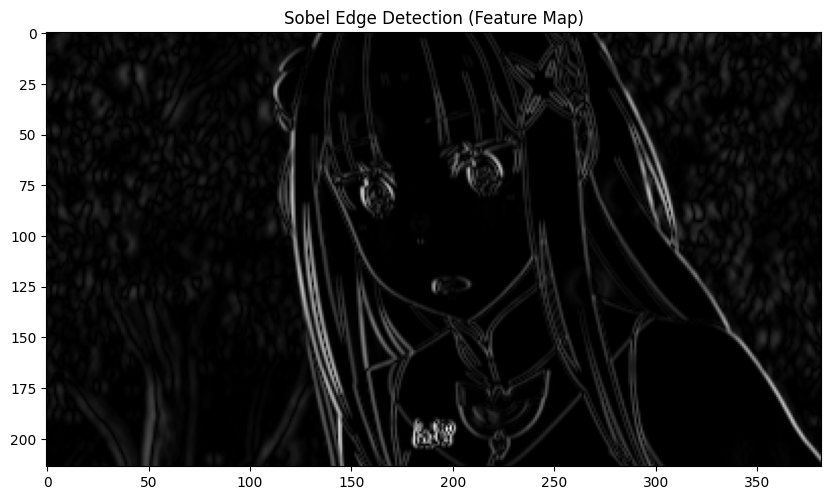

In [ ]:
# 延續上面的程式碼 做修改
# 轉成 垂直邊緣的feature map
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 影像I 的部分:
img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png")
img_small = img.resize((384,216))
arr = np.array(img_small)[:, :, :3]
print(arr.shape)
# Kernel 的部分:(先令2維的K_2d  這邊是sobel 偵測垂直邊緣)
K_2d = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
# np.stack 會把三個矩陣疊在一起，變成 (3, 3, 3)
K_3d = np.stack([K_2d, K_2d, K_2d], axis=2)
I = arr

# 定義: rgb的卷積 
def convolution_rgb(I, K):
    # I 的形狀假設為 (H, W, 3)
    # K 的形狀假設為 (kH, kW, 3)
    I_h, I_w, I_c = I.shape
    K_h, K_w, K_c = K.shape
    
    # 輸出依然是二維 (F_h, F_w)
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    F = np.zeros((F_h, F_w))
    
    for i in range(F_h):
        for j in range(F_w):
            # 這裡就是關鍵：I[i:i+K_h, j:j+K_w, :] 抓取的是一個 3x3x3 的方塊
            # numpy 的 * 運算子會自動處理對應位置相乘
            F[i, j] = np.sum(I[i:i+K_h, j:j+K_w, :] * K)

    return F

print (convolution_rgb(I,K_3d))

# 定義：繪圖的函示
def Transformimage(F):
    # 1. 處理負數：取絕對值
    # 我們只想知道「哪裡有線條」，不論是由亮轉暗還是由暗轉亮
    F_abs = np.absolute(F)

    # 2. 處理範圍：正規化到 0~1 (或 0~255)
    # 這是數學上的線性映射：(x - min) / (max - min)
    if F_abs.max() != F_abs.min(): # 避免除以 0
        F_norm = (F_abs - F_abs.min()) / (F_abs.max() - F_abs.min())
    else:
        F_norm = F_abs

    # 3. 繪圖
    plt.figure(figsize=(10, 10))
    plt.imshow(F_norm, cmap='gray') # 使用灰階色盤顯示特徵強度
    plt.title("Sobel Edge Detection (Feature Map)")
    plt.axis('on') # 是否開啟座標軸
    plt.show()

F = convolution_rgb(I, K_3d)
print(F)
Transformimage(F)


# 示範同一張圖用不同kernel 轉成不同的 feature Map

以芙莉蓮 這張美美的畫面做示範~
![alt text](<葬送的芙莉蓮 第二季 [38]_17：50_1778821895866-1.png>)

(216, 384, 3)


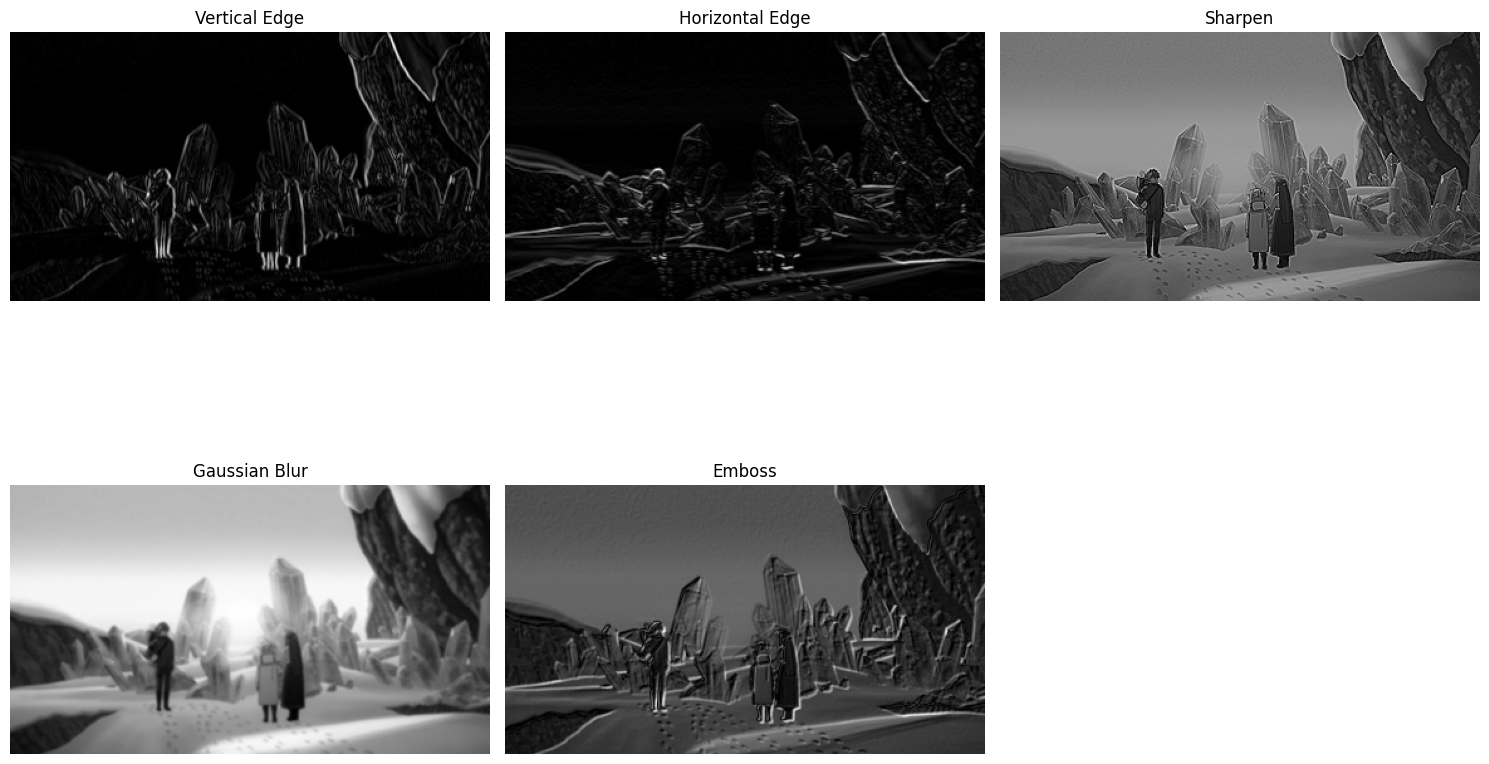

In [ ]:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 讀取圖片
img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png")
img_small = img.resize((384,216))

# RGB
I = np.array(img_small)[:, :, :3]

print(I.shape)

# 定義 kernels
kernels = {
    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]),

    "Horizontal Edge": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ]),

    "Sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ]),

    "Gaussian Blur": (1/16) * np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]),

    "Emboss": np.array([
        [-2, -1, 0],
        [-1,  1, 1],
        [ 0,  1, 2]
    ])
}

# RGB convolution
def convolution_rgb(I, K):

    I_h, I_w, I_c = I.shape
    K_h, K_w, K_c = K.shape
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    F = np.zeros((F_h, F_w))
    for i in range(F_h):
        for j in range(F_w):

            F[i, j] = np.sum(
                I[i:i+K_h, j:j+K_w, :] * K
            )
    return F
# normalization
def normalize_feature_map(F):
    F_abs = np.absolute(F)
    if F_abs.max() != F_abs.min():
        F_norm = ((F_abs - F_abs.min())/(F_abs.max() - F_abs.min()))
    else:
        F_norm = F_abs
    return F_norm

# plotting
plt.figure(figsize=(15, 10))
index = 1

for name, K_2d in kernels.items():
    # stack 成 RGB kernel
    K_3d = np.stack([K_2d, K_2d, K_2d], axis=2)
    # convolution
    F = convolution_rgb(I, K_3d)
    # normalize
    F_norm = normalize_feature_map(F)
    # subplot
    plt.subplot(2, 3, index)
    plt.imshow(F_norm, cmap='gray')
    plt.title(name)
    plt.axis('off')
    index += 1
plt.tight_layout()
plt.show()



Image Shape: (216, 384, 3)


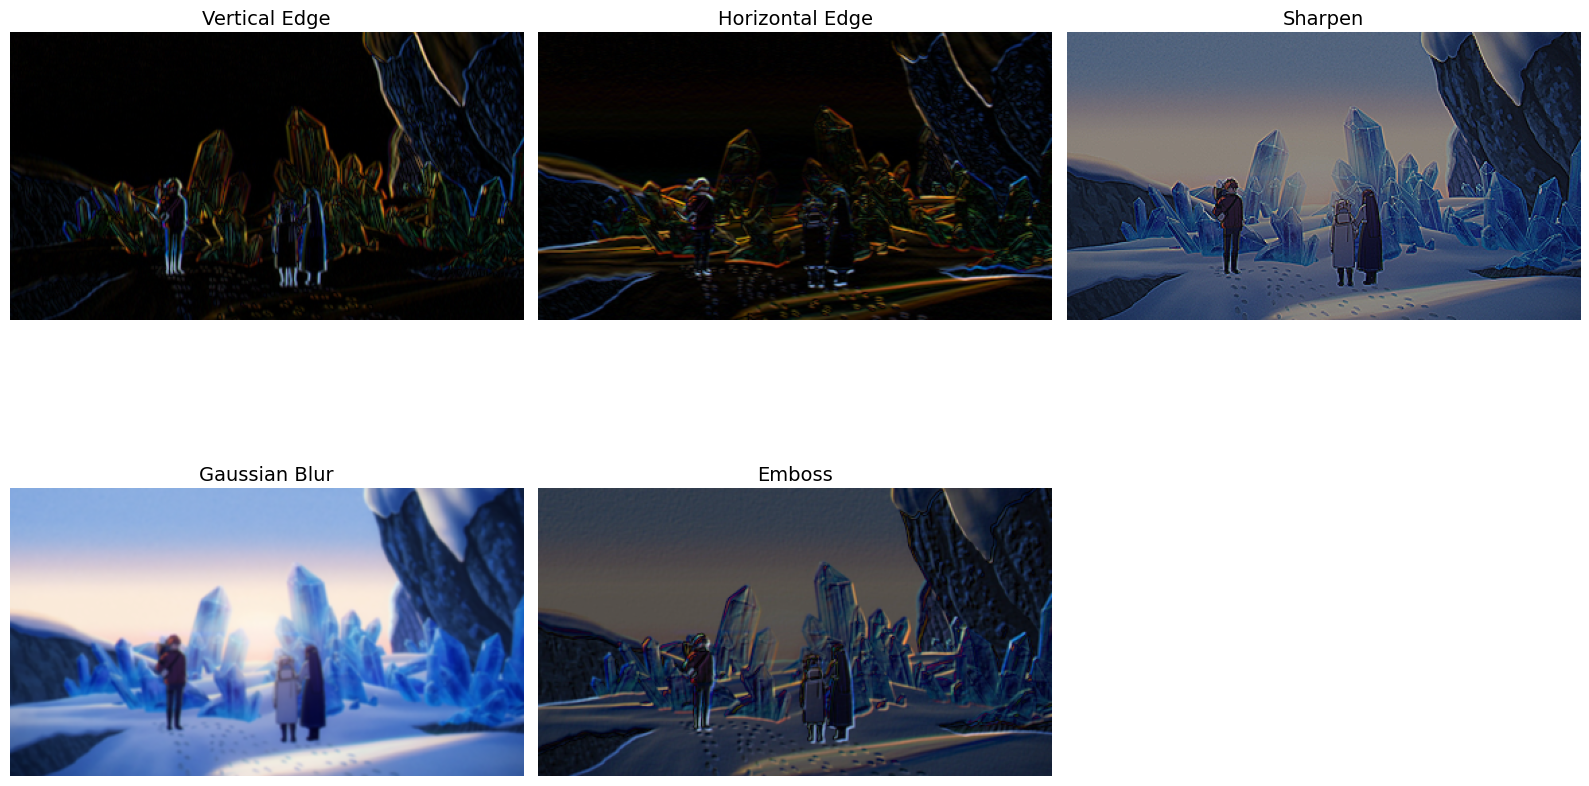

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 讀取圖片
img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png")

# resize
img_small = img.resize((384, 216))

# 轉 numpy array (RGB)
I = np.array(img_small)[:, :, :3]

print("Image Shape:", I.shape)

# 定義 kernels

kernels = {

    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]]),

    "Horizontal Edge": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]]),

    "Sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]]),

    "Gaussian Blur": (1/16) * np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]]),

    "Emboss": np.array([
        [-2, -1, 0],
        [-1,  1, 1],
        [ 0,  1, 2]])
}
# RGB convolution

def convolution_rgb_color(I, K):
    I_h, I_w, I_c = I.shape
    K_h, K_w, K_c = K.shape
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1

    # 保留 RGB 三個 channel
    F = np.zeros((F_h, F_w, 3))
    for i in range(F_h):
        for j in range(F_w):
            for c in range(3):
                F[i, j, c] = np.sum(I[i:i+K_h, j:j+K_w, c]*K[:, :, c])
    return F

# normalization

def normalize_rgb(F):
    # 取絕對值
    F_abs = np.absolute(F)
    # normalize 到 0~1
    if F_abs.max() != F_abs.min():
        F_norm = ((F_abs - F_abs.min())/(F_abs.max() - F_abs.min()))
    else:
        F_norm = F_abs
    return F_norm
# 畫圖
plt.figure(figsize=(16, 10))
index = 1
for name, K_2d in kernels.items():
    # stack 成 RGB kernel
    K_3d = np.stack([K_2d, K_2d, K_2d], axis=2)
    # convolution
    F = convolution_rgb_color(I, K_3d)
    # normalization
    F_norm = normalize_rgb(F)
    # subplot
    plt.subplot(2, 3, index)
    # 顯示彩色 feature map
    plt.imshow(F_norm)
    plt.title(name, fontsize=14)
    plt.axis('off')
    index += 1

plt.tight_layout()
plt.show()